# 학습된 모델 저장

- 학습이 완료된 모델을 파일로 저장하여, 이후 추가 학습이나 예측 서비스에 사용할 수 있도록 한다.
- 파이토치(PyTorch)는 **모델의 파라미터만 저장**하는 방법과 **모델의 구조와 파라미터를 모두 저장**하는 두 가지 방식을 제공한다.
- 저장 함수
  - `torch.save(저장할 객체, 저장 경로)`
- 보통 저장 파일의 확장자는 `.pt`나 `.pth`를 사용한다.

## 모델 전체 저장 및 불러오기

- 저장하기
  - `torch.save(model, 저장 경로)`
- 불러오기
  - `load_model = torch.load(저장 경로)`
- 모델 저장 시 **피클(pickle)**을 사용해 직렬화되므로, 모델을 불러오는 실행 환경에도 저장할 때 사용한 클래스 정의가 필요하다.


## 모델의 파라미터만 저장

-   모델을 구성하는 파라미터만 저장한다.
-   모델의 구조는 저장하지 않기 때문에 불러올 때 **모델을 먼저 생성하고 생성한 모델에 불러온 파라미터를 덮어씌운다.**
-   모델의 파라미터는 **state_dict** 형식으로 저장한다.

### state_dict

-   모델의 파라미터 Tensor들을 레이어 단위별로 나누어 저장한 Ordered Dictionary (OrderedDict)
-   `모델객체.state_dict()` 메소드를 이용해 조회한다.
-   모델의 state_dict을 조회 후 저장한다.
    -   `torch.save(model.state_dict(), "저장경로")`
-   생성된 모델에 읽어온 state_dict를 덮어씌운다.
    -   `new_model.load_state_dict(torch.load("state_dict저장경로"))`


## Checkpoint 저장 및 불러오기

- 학습이 끝나지 않은 모델을 저장하고, 나중에 이어서 학습시키려면 모델의 구조와 파라미터뿐만 아니라 optimizer, loss 함수 등 학습에 필요한 객체들도 함께 저장해야 한다.
- 딕셔너리(Dictionary)에 저장하려는 값들을 key-value 쌍으로 구성하여 `torch.save()`를 이용해 저장한다.

```python
# 저장
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': train_loss
}, "저장경로")

# 불러오기
model = MyModel()
optimizer = optim.Adam(model.parameters())

# 불러온 checkpoint를 이용해 이전 학습 상태 복원
checkpoint = torch.load("저장경로")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']
```

In [1]:
# 간단한 모델 정의
import torch
import torch.nn as nn

class MyModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(3, 4) # 3 X 4 + 4 
        self.lr2 = nn.Linear(4, 2)
        self.relu = nn.ReLU() # activation함수->파라미터가 없는 단순 계산함수. relu(X) = max(X, 0)
    def forward(self, X):
        X = self.lr1(X)
        X = self.relu(X)
        X = self.lr2(X)
        return X

In [2]:
# 모델 생성
model = MyModel()
model

MyModel(
  (lr1): Linear(in_features=3, out_features=4, bias=True)
  (lr2): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)

In [3]:
################################################
#  모델에 Layer들을 조회. 모델.instance변수명
################################################
lr_layer = model.lr1
lr_layer

Linear(in_features=3, out_features=4, bias=True)

In [4]:
################################################
#  Layer의 파라미터(weight/bias) 조회
################################################
lr1_weight = lr_layer.weight
lr1_bias = lr_layer.bias

In [5]:
lr1_weight

Parameter containing:
tensor([[-0.5720, -0.2232,  0.3117],
        [ 0.2860, -0.0552, -0.4126],
        [ 0.5469, -0.4900,  0.4201],
        [ 0.3852,  0.5160, -0.5523]], requires_grad=True)

In [6]:
lr1_bias

Parameter containing:
tensor([ 0.3363, -0.5694,  0.3712, -0.1264], requires_grad=True)

In [7]:
import os
os.makedirs("saved_models", exist_ok=True)

In [8]:
################################################
#  모델을 저장
################################################
torch.save(model, "saved_models/my_model.pt")

In [9]:
################################################
#  저장된 모델 Load
################################################
load_model = torch.load("saved_models/my_model.pt", weights_only=False)

In [10]:
load_model

MyModel(
  (lr1): Linear(in_features=3, out_features=4, bias=True)
  (lr2): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)

In [11]:
load_model.lr1.weight

Parameter containing:
tensor([[-0.5720, -0.2232,  0.3117],
        [ 0.2860, -0.0552, -0.4126],
        [ 0.5469, -0.4900,  0.4201],
        [ 0.3852,  0.5160, -0.5523]], requires_grad=True)

In [12]:
######################################################
# 모델의 파라미터들(weight들, bias들)만 저장/불러오기
######################################################
state_dict = model.state_dict()
state_dict

OrderedDict([('lr1.weight',
              tensor([[-0.5720, -0.2232,  0.3117],
                      [ 0.2860, -0.0552, -0.4126],
                      [ 0.5469, -0.4900,  0.4201],
                      [ 0.3852,  0.5160, -0.5523]])),
             ('lr1.bias', tensor([ 0.3363, -0.5694,  0.3712, -0.1264])),
             ('lr2.weight',
              tensor([[-0.0730, -0.3873,  0.2735,  0.1616],
                      [ 0.4837,  0.2581,  0.4712,  0.3527]])),
             ('lr2.bias', tensor([-0.4497, -0.3789]))])

In [13]:
state_dict.keys()

odict_keys(['lr1.weight', 'lr1.bias', 'lr2.weight', 'lr2.bias'])

In [14]:
###################
# state_dict 저장
################### 

torch.save(state_dict, "saved_models/my_model_parameter.pt")

In [ ]:
#####################
# state_dict load
#####################
sd = torch.load("saved_models/my_model_parameter.pt")  #weight_only=True (default)
sd

OrderedDict([('lr1.weight',
              tensor([[-0.5720, -0.2232,  0.3117],
                      [ 0.2860, -0.0552, -0.4126],
                      [ 0.5469, -0.4900,  0.4201],
                      [ 0.3852,  0.5160, -0.5523]])),
             ('lr1.bias', tensor([ 0.3363, -0.5694,  0.3712, -0.1264])),
             ('lr2.weight',
              tensor([[-0.0730, -0.3873,  0.2735,  0.1616],
                      [ 0.4837,  0.2581,  0.4712,  0.3527]])),
             ('lr2.bias', tensor([-0.4497, -0.3789]))])

In [16]:
# load한 state_dict를 모델 파라미터에 적용(덮어 씌운다.)
new_model = MyModel()
new_model.state_dict()

OrderedDict([('lr1.weight',
              tensor([[-0.3326,  0.2336,  0.1969],
                      [ 0.2684,  0.1383, -0.1769],
                      [-0.3796,  0.1233,  0.0513],
                      [ 0.4543,  0.5648, -0.3861]])),
             ('lr1.bias', tensor([-0.3457, -0.4520,  0.1685, -0.4256])),
             ('lr2.weight',
              tensor([[-0.0849,  0.2949, -0.2088,  0.3083],
                      [-0.2339, -0.3435, -0.2470,  0.2036]])),
             ('lr2.bias', tensor([0.1696, 0.3566]))])

In [17]:
new_model.load_state_dict(sd)

<All keys matched successfully>

In [18]:
new_model.state_dict()

OrderedDict([('lr1.weight',
              tensor([[-0.5720, -0.2232,  0.3117],
                      [ 0.2860, -0.0552, -0.4126],
                      [ 0.5469, -0.4900,  0.4201],
                      [ 0.3852,  0.5160, -0.5523]])),
             ('lr1.bias', tensor([ 0.3363, -0.5694,  0.3712, -0.1264])),
             ('lr2.weight',
              tensor([[-0.0730, -0.3873,  0.2735,  0.1616],
                      [ 0.4837,  0.2581,  0.4712,  0.3527]])),
             ('lr2.bias', tensor([-0.4497, -0.3789]))])

In [ ]:
# torchinfo 패키지 설치: 파이토치 모델 구조를 조사해주는 패키지.
# !uv pip install torchinfo

Resolved 1 package in 69ms
Prepared 1 package in 43ms
Installed 1 package in 42ms
 + torchinfo==1.8.0


In [22]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
MyModel                                  --
├─Linear: 1-1                            16
├─Linear: 1-2                            10
├─ReLU: 1-3                              --
Total params: 26
Trainable params: 26
Non-trainable params: 0

In [25]:
# input data 의 shape을 지정하면 각 Layer의 output shape을 출력한다.
summary(model, (100, 3))

# p = model(X)  X의 shape

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [100, 2]                  --
├─Linear: 1-1                            [100, 4]                  16
├─ReLU: 1-2                              [100, 4]                  --
├─Linear: 1-3                            [100, 2]                  10
Total params: 26
Trainable params: 26
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.01

# 문제 유형별 MLP 네트워크
- 해결하려는 문제 유형에 따라 출력 Layer의 구조가 바뀐다.
- 딥러닝 구조에서 **Feature를 추출하는 Layer 들을 Backbone** 이라고 하고 **추론하는 Layer들을 Head** 라고 한다. 


> - MLP(Multi Layer Perceptron), DNN(Deep Neural Network), ANN(Artificial Neural Network)
>     -   Fully Connected Layer(nn.Linear)로 구성된 딥러닝 모델
>     -   input feature들 모두에 대응하는 weight들(가중치)을 사용한다.
> 

## Boston Housing Dataset - **Regression(회귀) 문제**

보스턴 주택가격 dataset은 다음과 같은 속성을 바탕으로 해당 타운 주택 가격의 중앙값을 예측하는 문제.

-   CRIM: 범죄율
-   ZN: 25,000 평방피트당 주거지역 비율
-   INDUS: 비소매 상업지구 비율
-   CHAS: 찰스강에 인접해 있는지 여부(인접:1, 아니면:0)
-   NOX: 일산화질소 농도(단위: 0.1ppm)
-   RM: 주택당 방의 수
-   AGE: 1940년 이전에 건설된 주택의 비율
-   DIS: 5개의 보스턴 직업고용센터와의 거리(가중 평균)
-   RAD: 고속도로 접근성
-   TAX: 재산세율
-   PTRATIO: 학생/교사 비율
-   B: 흑인 비율
-   LSTAT: 하위 계층 비율
    <br><br>
-   **Target**
    -   MEDV: 타운의 주택가격 중앙값(단위: 1,000달러)


In [1]:
import torch
import torch.nn as nn 
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import pandas as pd
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [2]:
boston = pd.read_csv('data/boston_dataset.csv')
X_boston = boston.drop(columns='MEDV').values
y_boston = boston['MEDV'].values.reshape(-1, 1)  # (506, ) -> (506, 1)
X_boston.shape, y_boston.shape

((506, 13), (506, 1))

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_boston, y_boston, test_size=0.2, random_state=0
)

In [4]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
X_train_scaled.dtype, y_train.dtype

(dtype('float64'), dtype('float64'))

In [7]:
# Dataset 생성
trainset_boston = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32) #dtype은 모델의 dtype인 float32로 설정.
)
testset_boston = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32)
)

len(trainset_boston), len(testset_boston)

(404, 102)

In [8]:
# DataLoader
train_loader_boston = DataLoader(
    trainset_boston, batch_size=202, shuffle=True, drop_last=True
)
test_loader_boston = DataLoader(
    testset_boston, batch_size=102
)

len(train_loader_boston), len(test_loader_boston)

(2, 1)

In [9]:
# 모델 class 정의
## 회귀 - Output Layer의 unit 수: y의 개수 (K, 1)
##      - Output Layer의 Activation 함수 - 보통은 주지 않는다.

class BostonModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(13, 32) # input layer 처리 
        self.lr2 = nn.Linear(32, 16)
        # output layer
        self.lr3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, X):
        out = self.lr1(X)
        out = self.relu(out)
        out = self.lr2(out)
        out = self.relu(out)
        output = self.lr3(out)
        return output


In [16]:
# 학습
## 모델 생성
boston_model = BostonModel().to(device)  # model, X, y 는 같은 device
summary(boston_model, (100, 13), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
BostonModel                              [100, 1]                  --
├─Linear: 1-1                            [100, 32]                 448
├─ReLU: 1-2                              [100, 32]                 --
├─Linear: 1-3                            [100, 16]                 528
├─ReLU: 1-4                              [100, 16]                 --
├─Linear: 1-5                            [100, 1]                  17
Total params: 993
Trainable params: 993
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.10
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.00
Estimated Total Size (MB): 0.05

In [17]:
## 손실함수 - 회귀: MSELoss
loss_fn = nn.MSELoss()
## 옵티마이저 
optimizer = torch.optim.Adam(boston_model.parameters(), lr=0.001) # 모델의 파라미터, learning_rate

In [ ]:
epochs = 2000
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):
    #######################
    # 학습
    #######################
    boston_model.train()
    train_loss = 0.0
    for X, y in train_loader_boston:
        # 1. X, y 를 device로 이동
        X, y = X.to(device), y.to(device)
        # 2. 추론
        pred = boston_model(X)
        # 3. 오차계산
        loss = loss_fn(pred, y)
        # 4. grad 계산
        loss.backward()
        # 5. 파라미터 업데이트
        optimizer.step()
        # 6. 파라미터의 gradient초기화
        optimizer.zero_grad()

        train_loss += loss.item()

    # 1 epoch loss
    train_loss = train_loss / len(train_loader_boston)

    ########################
    # 검증 - 1 epoch 학습한 것에 대한 검증
    ########################
    boston_model.eval() # 검증, 평가, 추론 하는 모델에 설정.
    val_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in test_loader_boston:
            # 1. X, y를 device 이동
            X_val, y_val = X_val.to(device), y_val.to(device)
            # 2. 추론
            pred_val = boston_model(X_val)
            # 3. 검증 - 평가지표 계산 (회귀: MSE)
            val_loss += loss_fn(pred_val, y_val).item()
    val_loss /= len(test_loader_boston)   # val_loss 평균

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    if epoch % 100 == 0 or epoch == (epochs-1):
        print(f"[{epoch+1}/{epochs}] train loss: {train_loss}, val_loss: {val_loss}")

[1/2000] train loss: 2.172089099884033, val_loss: 17.45222282409668
[101/2000] train loss: 2.059131443500519, val_loss: 17.08451271057129
[201/2000] train loss: 1.9646012783050537, val_loss: 16.94742774963379
[301/2000] train loss: 1.864802062511444, val_loss: 16.913549423217773
[401/2000] train loss: 1.7784906029701233, val_loss: 16.826162338256836
[501/2000] train loss: 1.702211320400238, val_loss: 16.821943283081055
[601/2000] train loss: 1.6339223384857178, val_loss: 16.86918067932129
[701/2000] train loss: 1.5590355396270752, val_loss: 16.98314666748047
[801/2000] train loss: 1.4889277815818787, val_loss: 16.992841720581055
[901/2000] train loss: 1.4162057042121887, val_loss: 17.120502471923828
[1001/2000] train loss: 1.3570854663848877, val_loss: 17.2960205078125
[1101/2000] train loss: 1.2970072627067566, val_loss: 17.561479568481445
[1201/2000] train loss: 1.246712327003479, val_loss: 17.773895263671875
[1301/2000] train loss: 1.2028489708900452, val_loss: 17.831514358520508
[1

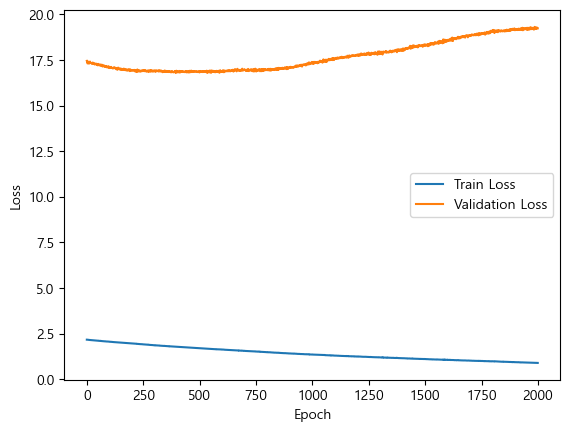

In [ ]:
# 학습 도중 저장한 평가 지표 시각화
plt.plot(range(epochs), train_loss_list, label="Train Loss")
plt.plot(range(epochs), val_loss_list, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# plt.ylim(0, 40)

plt.legend()
plt.show()

In [26]:
# Testset으로 최종 검증
boston_model.eval() # 검증, 평가, 추론 하는 모델에 설정.
test_loss = 0.0
with torch.no_grad():
    for X_test, y_test in test_loader_boston:
        # 1. X, y를 device 이동
        X_test, y_test = X_test.to(device), y_test.to(device)
        # 2. 추론
        pred_test = boston_model(X_test)
        # 3. 검증 - 평가지표 계산 (회귀: MSE)
        test_loss += loss_fn(pred_test, y_test).item()
test_loss /= len(test_loader_boston)   # val_loss 평균

print("최종 평가:", test_loss)

최종 평가: 19.233898162841797


In [41]:
# 이 함수는 grad를 계산할 필요가 없는 함수임을 선언. with torch.no_grad()대신
@torch.no_grad() 
def test(model, dataloader, device="cpu"):
    model.eval() # 검증, 평가, 추론 하는 모델에 설정.
    test_loss = 0.0
    # with torch.no_grad():
    for X_test, y_test in dataloader:
        # 1. X, y를 device 이동
        X_test, y_test = X_test.to(device), y_test.to(device)
        # 2. 추론
        pred_test = model(X_test)
        # 3. 검증 - 평가지표 계산 (회귀: MSE)
        test_loss += loss_fn(pred_test, y_test).item()
    test_loss /= len(dataloader)   # val_loss 평균

    print("최종 평가:", test_loss)

In [34]:
test(boston_model, train_loader_boston)

최종 평가: 0.8951453864574432


In [35]:
test(boston_model, test_loader_boston)

최종 평가: 19.233898162841797


In [36]:
# 모델 저장.
## 파라미터만 저장, 모델 전체를 저장
save_path = "models/boston_model.pt"
torch.save(boston_model, save_path)

In [39]:
# 모델 로드
load_boston_model = torch.load(save_path, weights_only=False)
load_boston_model = load_boston_model.to(device)
summary(load_boston_model, (100, 13), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
BostonModel                              [100, 1]                  --
├─Linear: 1-1                            [100, 32]                 448
├─ReLU: 1-2                              [100, 32]                 --
├─Linear: 1-3                            [100, 16]                 528
├─ReLU: 1-4                              [100, 16]                 --
├─Linear: 1-5                            [100, 1]                  17
Total params: 993
Trainable params: 993
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.10
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.00
Estimated Total Size (MB): 0.05

In [42]:
test(load_boston_model, test_loader_boston, device=device)

최종 평가: 19.233898162841797


## 분류 (Classification)

### Fashion MNIST Dataset - **다중분류(Multi-Class Classification) 문제**

10개의 범주(category)와 70,000개의 흑백 이미지로 구성된 [패션 MNIST](https://github.com/zalandoresearch/fashion-mnist) 데이터셋.
이미지는 해상도(28x28 픽셀)가 낮고 다음처럼 개별 의류 품목을 나타낸다:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>그림</b> <a href="https://github.com/zalandoresearch/fashion-mnist">패션-MNIST 샘플</a> (Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

- **Feature**이미지는 28x28 크기이며 Gray scale이다.
- **Target**은 총 10개의 class로 구성되어 있으며 각 class의 class 이름은 다음과 같다.

| 레이블 | 클래스       |
|--------|--------------|
| 0      | T-shirt/top |
| 1      | Trousers    |
| 2      | Pullover    |
| 3      | Dress       |
| 4      | Coat        |
| 5      | Sandal      |
| 6      | Shirt       |
| 7      | Sneaker     |
| 8      | Bag         |
| 9      | Ankle boot  |

> #### 학습 도중 모델 저장
>
> - 학습 도중 가장 좋은 성능을 보이는 모델이 나올 수 있다.
> - 학습 도중 모델을 저장하는 방법
>   1. 각 에폭이 끝날 때 마다 모델을 저장한다.
>   2. 한 에폭 학습 후 성능 개선이 있으면 모델을 저장하여 가장 성능 좋은 모델만 저장되도록 한다.
>      - 최고 성능 점수(best score)와 현재 에폭의 성능을 비교하여, 성능이 개선되었을 경우 모델을 저장(덮어쓰기)한다.
>
> #### 조기 종료(Early Stopping)
>
> - 학습 도중 성능 개선이 나타나지 않으면, 중간에 학습을 종료하도록 구현한다.
> - 에폭 수를 충분히 길게 설정한 뒤, 특정 횟수 동안 성능 개선이 없으면 학습을 조기 종료하도록 구현한다.


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms 
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"
# device
epochs = 100
batch_size = 200
learning_rate = 0.001

In [ ]:
# Dataset load 하고 확인
f_trainset = datasets.FashionMNIST(
    root="datasets", train=True, download=True
)
f_testset = datasets.FashionMNIST(
    root="datasets", train=False, download=True
)
len(f_trainset), len(f_testset)

100.0%
100.0%
100.0%
100.0%


(60000, 10000)

In [5]:
# 데이터 확인
f_trainset[0]

(<PIL.Image.Image image mode=L size=28x28>, 9)

In [45]:
import random
idx = random.randint(0, 60000)
print(f_trainset[idx][1], f_trainset.classes[f_trainset[idx][1]])
f_trainset[idx][0]

2 Pullover


In [40]:
f_trainset.class_to_idx
f_trainset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [2]:
# Dataset 생성 + 전처리

f_trainset = datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=transforms.ToTensor()
)
f_testset = datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=transforms.ToTensor()
)
# trainset을 train/valid set으로 분리 (50000, 10000)
f_trainset, f_validset = random_split(f_trainset, [50000, 10000])

print(len(f_trainset), len(f_testset), len(f_validset))

# DataLoader 생성
f_train_loader = DataLoader(f_trainset, batch_size=batch_size, shuffle=True, drop_last=True)
f_test_loader = DataLoader(f_testset, batch_size=batch_size)
f_valid_loader = DataLoader(f_validset, batch_size=batch_size)
print(len(f_train_loader), len(f_test_loader), len(f_valid_loader))

50000 10000 10000
250 50 50


In [3]:
x0 = f_trainset[0][0]
type(x0), x0.shape, x0.dtype

(torch.Tensor, torch.Size([1, 28, 28]), torch.float32)

In [4]:
#### 모델 클래스 정의
class FashionMNISTModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(28*28, 512) # 입력층
        # Hidden Layer - feature vector를 추출
        self.lr2 = nn.Linear(512, 256)
        self.lr3 = nn.Linear(256, 128)
        self.lr4 = nn.Linear(128, 64)
        self.lr5 = nn.Linear(64, 32)
        # 출력층 - out_features개수: y의 class 개수. 
        #                           정답이 class일 확률을 계산할 때 사용 값(logit)
        self.lr6 = nn.Linear(32, 10)
        # 활성(Activation)함수 -> ReLU
        self.relu = nn.ReLU()

    def forward(self, X):
        # X: (1, 28, 28)-> 1차원(1*28*28, ) -> Linear
        out = nn.Flatten()(X) #nn.Flatten() : 0축은 놔두고 1축 부터 flatten한다.

        # 선형(Linear) -> 비선형(ReLU)
        out = self.lr1(out)    # self.relu(self.lr1(out))
        out = self.relu(out)

        out = self.lr2(out)
        out = self.relu(out)

        out = self.lr3(out)
        out = self.relu(out)

        out = self.lr4(out)
        out = self.relu(out)

        out = self.lr5(out)
        out = self.relu(out)

        output = self.lr6(out)
        return output

In [12]:
# 모델 생성
f_model = FashionMNISTModel().to(device)
print(f_model)
summary(f_model, (batch_size, 1, 28, 28), device=device)

FashionMNISTModel(
  (lr1): Linear(in_features=784, out_features=512, bias=True)
  (lr2): Linear(in_features=512, out_features=256, bias=True)
  (lr3): Linear(in_features=256, out_features=128, bias=True)
  (lr4): Linear(in_features=128, out_features=64, bias=True)
  (lr5): Linear(in_features=64, out_features=32, bias=True)
  (lr6): Linear(in_features=32, out_features=10, bias=True)
  (relu): ReLU()
)


Layer (type:depth-idx)                   Output Shape              Param #
FashionMNISTModel                        [200, 10]                 --
├─Linear: 1-1                            [200, 512]                401,920
├─ReLU: 1-2                              [200, 512]                --
├─Linear: 1-3                            [200, 256]                131,328
├─ReLU: 1-4                              [200, 256]                --
├─Linear: 1-5                            [200, 128]                32,896
├─ReLU: 1-6                              [200, 128]                --
├─Linear: 1-7                            [200, 64]                 8,256
├─ReLU: 1-8                              [200, 64]                 --
├─Linear: 1-9                            [200, 32]                 2,080
├─ReLU: 1-10                             [200, 32]                 --
├─Linear: 1-11                           [200, 10]                 330
Total params: 576,810
Trainable params: 576,810
Non-trainable pa

In [13]:
# loss함수 - 다중분류: CrossEntropyLoss() 모델예측값: softmax(), y(정답): OneHotEncoding 변환후 loss계산
loss_fn = nn.CrossEntropyLoss()
# optimizer
optimizer = torch.optim.Adam(f_model.parameters(), lr=learning_rate)

In [14]:
@torch.no_grad()
def f_mnist_test(model, dataloader, device="cpu"):
    """평가함수 - loss와 accuracy 계산해서 반환."""
    model = model.to(device)
    model.eval()

    loss = 0.0
    accuracy = 0.0
    for X, y in dataloader:
        # 1. X, y를 device로 이동
        X, y = X.to(device), y.to(device)
        # 2. 추론
        pred = model(X) # pred: class별 logit(확률 계산 전 값)
        pred_label = torch.argmax(pred, dim=-1) # pred.shape: (batch, 10) -> pred_label (batch, 1)

        # 3. 검증/평가 (loss, accuracy)
        loss += loss_fn(pred, y).item() # loss값 누적
        accuracy +=  torch.sum(pred_label == y).item()

    loss /= len(dataloader) # loss/누적횟수 = 평균
    accuracy /= len(dataloader.dataset)
    return loss, accuracy # {"loss":loss, "accuracy":acc}

In [15]:
##### 학습
import time

train_loss_list = []
val_loss_list = []
val_acc_list = []

# 학습 중 성능이 개선이 되면 모델을 저장.
# 지정한 epoch 동안 성능이 개선되지 않으면 학습을 중지(early stopping)

best_score = torch.inf  # 성능개선여부를 validation loss로 모니터링. 시작: 제일큰수(무한)
save_model_path = "saved_models/fashion_mnist_model.pth" # 성능개선된 epoch의 모델을 저장할 경로

# 조기종료
patience = 10 # 몇 epoch동안 성능 개선을 확인할 지.
stop_count = 0 # 성능개선이 안될 때 몇번째 학습중인지 저장할 변수. patience == stop_count 종료

s = time.time()
for epoch in range(epochs):
    ########## train
    f_model.train()
    train_loss = 0.0
    for X_train, y_train in f_train_loader: # batch단위로 학습
        # 1. model과 같은 device로 X, y를 이동
        X_train, y_train = X_train.to(device), y_train.to(device)
        
        # 2. 추론
        pred_train = f_model(X_train)

        # 3. loss 계산
        loss_train = loss_fn(pred_train, y_train)

        # 4. gradient값 계산
        loss_train.backward()

        # 5. parameter update
        optimizer.step()

        # 6. parameter grad값 초기화
        optimizer.zero_grad()

        train_loss += loss_train.item() # 현재 step의 loss를 train_loss에 누적

    # 1 epoch 학습한 loss를 계산(평균)
    train_loss /= len(f_train_loader)
    train_loss_list.append(train_loss)

    ########## validation
    f_model.eval()
    val_loss, val_acc = f_mnist_test(
        model=f_model, dataloader=f_valid_loader, device=device
    )
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    # 현재 epoch 학습 결과 로그 출력
    print(f"[{epoch+1}/{epochs}] train loss: {train_loss}, val loss: {val_loss}, val acc: {val_acc}")

    ####### 성능개선시 모델 저장, 성능개선이 없으면 조기종료 처리
    # 성능: validation loss 기준. (작을수록 좋은 성능)
    if val_loss < best_score: # 성능 개선
        # 저장, best_score를 val_loss로 변경
        torch.save(f_model, save_model_path)
        # 저장했다는 로그 출력
        print(f">>>>>>> {epoch+1}에서 모델저장-이전 score: {best_score}, 개선된 score: {val_loss}")
        best_score = val_loss
        # stop_count를 초기화
        stop_count = 0
        
    else: # 성능개선이 안됨
        stop_count += 1
        if patience == stop_count:
            print(f">>>>>>{epoch+1}에서 학습을 조기종료합니다. val loss가 {best_score}에서 개선되지 않음")
            break

e = time.time()
print("걸린시간(초):", e-s)


[1/100] train loss: 0.7971756687164306, val loss: 0.5147349935770035, val acc: 0.8226
>>>>>>> 1에서 모델저장-이전 score: inf, 개선된 score: 0.5147349935770035
[2/100] train loss: 0.46414954245090484, val loss: 0.42980104744434355, val acc: 0.8458
>>>>>>> 2에서 모델저장-이전 score: 0.5147349935770035, 개선된 score: 0.42980104744434355
[3/100] train loss: 0.3938112977743149, val loss: 0.37781012415885923, val acc: 0.864
>>>>>>> 3에서 모델저장-이전 score: 0.42980104744434355, 개선된 score: 0.37781012415885923
[4/100] train loss: 0.35840159803628924, val loss: 0.3761895227432251, val acc: 0.8649
>>>>>>> 4에서 모델저장-이전 score: 0.37781012415885923, 개선된 score: 0.3761895227432251
[5/100] train loss: 0.3338037367463112, val loss: 0.3608608967065811, val acc: 0.8698
>>>>>>> 5에서 모델저장-이전 score: 0.3761895227432251, 개선된 score: 0.3608608967065811
[6/100] train loss: 0.3131494709849358, val loss: 0.3492723017930984, val acc: 0.8774
>>>>>>> 6에서 모델저장-이전 score: 0.3608608967065811, 개선된 score: 0.3492723017930984
[7/100] train loss: 0.30025145

In [17]:
# 학습 결과 시각화
import pandas as pd
train_result = pd.DataFrame({
    "train loss": train_loss_list,
    "valid loss": val_loss_list,
    "val accuracy": val_acc_list
})
train_result.rename_axis(index="Epoch", inplace=True)
train_result.head()

,train loss,valid loss,val accuracy
Epoch,,,
0,0.797176,0.514735,0.8226
1,0.464150,0.429801,0.8458
2,0.393811,0.377810,0.8640
3,0.358402,0.376190,0.8649
4,0.333804,0.360861,0.8698


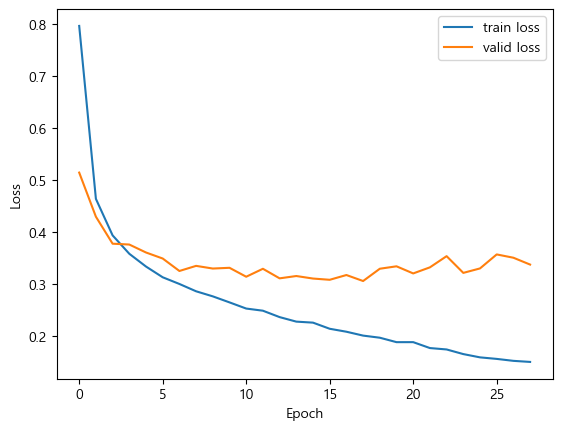

In [19]:
train_result[["train loss", "valid loss"]].plot(ylabel="Loss");

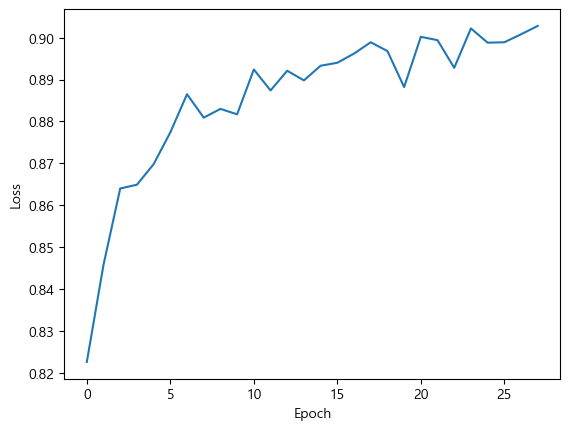

In [20]:
train_result['val accuracy'].plot(ylabel="Loss");

In [22]:
###### 저장된 모델(best model) load 후 최종 테스트
f_load_model = torch.load(save_model_path, weights_only=False)
f_load_model

FashionMNISTModel(
  (lr1): Linear(in_features=784, out_features=512, bias=True)
  (lr2): Linear(in_features=512, out_features=256, bias=True)
  (lr3): Linear(in_features=256, out_features=128, bias=True)
  (lr4): Linear(in_features=128, out_features=64, bias=True)
  (lr5): Linear(in_features=64, out_features=32, bias=True)
  (lr6): Linear(in_features=32, out_features=10, bias=True)
  (relu): ReLU()
)

In [23]:
test_loss, test_acc = f_mnist_test(
    model=f_load_model, dataloader=f_test_loader, device=device
)

In [24]:
print(test_loss, test_acc)

0.34174288243055345 0.8864


In [28]:
x, y = f_testset[0]
print(x.shape)
x = x.unsqueeze(dim=0)
print(x.shape)

torch.Size([1, 28, 28])
torch.Size([1, 1, 28, 28])


In [31]:
with torch.no_grad():
    p = f_load_model(x)

In [33]:
# 정답 class
p.argmax(dim=-1)

tensor([9])

In [42]:
# 정답 확률
print(p.shape)
proba = p.softmax(dim=-1)
print(proba)

m = proba.max(dim=-1)
print("확률:", m.values, "label:", m.indices)

torch.Size([1, 10])
tensor([[2.3420e-06, 2.3574e-05, 3.0834e-08, 3.9566e-07, 6.9202e-07, 2.2850e-04,
         5.3124e-07, 3.5862e-02, 2.3001e-05, 9.6386e-01]])
확률: tensor([0.9639]) label: tensor([9])


In [46]:
f_testset.classes[m.indices.item()]

'Ankle boot'

In [47]:
f_testset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

### 위스콘신 유방암 데이터셋 - **이진분류(Binary Classification) 문제**

-   **이진 분류 문제 처리 모델의 두가지 방법**
    1. positive(1)일 확률을 출력하도록 구현
        - output layer: units=1, activation='sigmoid'
        - loss: binary_crossentropy
    2. negative(0)일 확률과 positive(1)일 확률을 출력하도록 구현 => 다중분류 처리 방식으로 해결
        - output layer: units=2, activation='softmax', y(정답)은 one hot encoding 처리
        - loss: categorical_crossentropy
-   위스콘신 대학교에서 제공한 종양의 악성/양성여부 분류를 위한 데이터셋
-   Feature
    -   종양에 대한 다양한 측정값들
-   Target의 class
    -   0 - malignant(악성종양)
    -   1 - benign(양성종양)


In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [4]:
# Dataset
X, y = load_breast_cancer(return_X_y=True)
print(X.shape, y.shape)

y = y.reshape(-1, 1)
print("reshape후:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=0)

(569, 30) (569,)
reshape후: (569, 1)


In [5]:
# 전처리
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Dataset
## 모델의 weight, bias -> float32. X, y는 weight, bias와 계산을 하게 되기 때문에 타입을 맞춰준다.
trainset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),  
    torch.tensor(y_train, dtype=torch.float32)
)
testset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32), 
    torch.tensor(y_test, dtype=torch.float32)
)

In [7]:
# class name <-> class index
classes = np.array(["악성종양", "양성종양"])
class_to_idx = {"악성종양":0, "양성종양":1}

trainset.classes = classes
trainset.class_to_idx = class_to_idx

testset.classes = classes
testset.class_to_idx = class_to_idx

In [8]:
# DataLoader
train_loader = DataLoader(trainset, batch_size=200, shuffle=True, drop_last=True)
test_loader = DataLoader(testset, batch_size=100)

In [9]:
######### 모델 정의
class BCModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(30, 16)
        self.lr2 = nn.Linear(16, 8)
        # 출력층 - out_features: 1 - 양성(positive)일 확률을 출력
        self.lr3 = nn.Linear(8, 1)
        # 은닉층의 활성(activation)함수 - ReLU
        self.relu = nn.ReLU()
        # 출력층의 활성(activation)함수 - Sigmoid(Logistic)
        self.sigmoid = nn.Sigmoid()

    def forward(self, X):
        out = self.lr1(X)
        out = self.relu(out)

        out = self.lr2(out)
        out = self.relu(out)

        out = self.lr3(out)
        output = self.sigmoid(out)
        return output 

In [12]:
from torchinfo import summary
# 생성
bc_model = BCModel().to(device)
print(bc_model)
summary(bc_model, (100, 30), device=device)

BCModel(
  (lr1): Linear(in_features=30, out_features=16, bias=True)
  (lr2): Linear(in_features=16, out_features=8, bias=True)
  (lr3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


Layer (type:depth-idx)                   Output Shape              Param #
BCModel                                  [100, 1]                  --
├─Linear: 1-1                            [100, 16]                 496
├─ReLU: 1-2                              [100, 16]                 --
├─Linear: 1-3                            [100, 8]                  136
├─ReLU: 1-4                              [100, 8]                  --
├─Linear: 1-5                            [100, 1]                  9
├─Sigmoid: 1-6                           [100, 1]                  --
Total params: 641
Trainable params: 641
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.06
Input size (MB): 0.01
Forward/backward pass size (MB): 0.02
Params size (MB): 0.00
Estimated Total Size (MB): 0.03

In [13]:
# 이진분류 loss 함수 (모델출력: 양성일 확률) -  Binary Crossentropy Loss
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(bc_model.parameters(), lr=0.01)

In [17]:
a = torch.tensor([[True], [True], [False]])
b = a.type(torch.int8)
b

tensor([[1],
        [1],
        [0]], dtype=torch.int8)

In [18]:
@torch.no_grad()
def bc_test(model, dataloader, loss_fn, device='cpu'):
    model = model.to(device)
    model.eval()

    loss = 0.0
    accuracy = 0.0

    for X, y in dataloader:
        # 1. 이동
        X, y = X.to(device), y.to(device)

        # 2. 추론
        pred = model(X) #pred shape: (batch, 1) 1: positive일 확률
        pred_label = (pred > 0.5).type(torch.int32) # bool tensor의 타입을 int32로 변환.True: 1, False: 0
        # 3. 검증 (loss, acc)
        loss += loss_fn(pred, y).item()
        accuracy += torch.sum(pred_label == y).item()

    loss /= len(dataloader)
    accuracy /= len(dataloader.dataset)
    return loss, accuracy

In [19]:
######### 학습 - 성능(val loss)개선시 저장, 조기종료
epochs = 1000
patience = 10
stop_count = 0
best_score = torch.inf 

train_loss_list = []
val_loss_list = []
val_acc_list = []

save_bc_model_path = "saved_models/bc_model.pth"

for epoch in range(epochs):
    ###### train
    bc_model.train()
    train_loss = 0.0
    for X_train, y_train in train_loader:        
        # 1. 이동
        X_train, y_train = X_train.to(device), y_train.to(device)

        # 2. 추론
        pred_train = bc_model(X_train)

        # 3. loss 계산
        loss = loss_fn(pred_train, y_train)

        # 4. grad계산
        loss.backward()

        # 5. 파라미터 업데이트
        optimizer.step()

        # 6. grad 초기화
        optimizer.zero_grad()

        # train loss 누적
        train_loss += loss.item()
    
    # train loss 계산 
    train_loss /= len(train_loader)
    train_loss_list.append(train_loss)

    ###### validation
    bc_model.eval()
    valid_loss = 0.0
    valid_acc = 0.0

    valid_loss, valid_acc = bc_test(
        model=bc_model, dataloader=test_loader, loss_fn=loss_fn, device=device
    )
    val_loss_list.append(valid_loss)
    val_acc_list.append(valid_acc)

    # 로그출력
    print(f"[{epoch+1}/{epochs}] train loss: {train_loss}, val loss: {valid_loss}, val acc: {valid_acc}")

    ### 모델 저장 및 조기종료
    if valid_loss < best_score: #성능개선
        torch.save(bc_model, save_bc_model_path)
        print(f">>>>>>>> {epoch+1}에서 저장. {best_score} -> {valid_loss}")
        best_score = valid_loss
        stop_count = 0 # 조기종료 관련
    else: # 개선안됨 - 조기종료
        stop_count += 1
        if patience == stop_count:
            print(f">>>>>>>> {epoch} 에폭에서 조기종료")
            break

[1/1000] train loss: 0.6861153542995453, val loss: 0.6377457678318024, val acc: 0.8531468531468531
>>>>>>>> 1에서 저장. inf -> 0.6377457678318024
[2/1000] train loss: 0.6132059693336487, val loss: 0.5607477426528931, val acc: 0.8951048951048951
>>>>>>>> 2에서 저장. 0.6377457678318024 -> 0.5607477426528931
[3/1000] train loss: 0.529356837272644, val loss: 0.47643984854221344, val acc: 0.9090909090909091
>>>>>>>> 3에서 저장. 0.5607477426528931 -> 0.47643984854221344
[4/1000] train loss: 0.4381321519613266, val loss: 0.39340466260910034, val acc: 0.9090909090909091
>>>>>>>> 4에서 저장. 0.47643984854221344 -> 0.39340466260910034
[5/1000] train loss: 0.34598684310913086, val loss: 0.32331499457359314, val acc: 0.916083916083916
>>>>>>>> 5에서 저장. 0.39340466260910034 -> 0.32331499457359314
[6/1000] train loss: 0.28295959532260895, val loss: 0.2706446796655655, val acc: 0.9090909090909091
>>>>>>>> 6에서 저장. 0.32331499457359314 -> 0.2706446796655655
[7/1000] train loss: 0.21445327997207642, val loss: 0.2309732139

In [20]:
######### 저장된 모델 로드
load_bc_model = torch.load(save_bc_model_path, weights_only=False)
load_bc_model

BCModel(
  (lr1): Linear(in_features=30, out_features=16, bias=True)
  (lr2): Linear(in_features=16, out_features=8, bias=True)
  (lr3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [21]:
###### 추론 함수 #######
def predict_bc(model, X, device="cpu"):
    # model로 X를 추론한 결과를 반환
    # label, 확률
    model = model.to(device)
    X = X.to(device)
    model.eval()
    result = []
    with torch.no_grad():
        pred_proba = model(X)
        pred_class = (pred_proba > 0.5).type(torch.int32)
        for class_index, proba in zip(pred_class, pred_proba):
            # print(class_index, proba if class_index.item() == 1 else 1-proba)
            result.append((class_index.item(), proba if class_index.item() == 1 else 1-proba))
        return result

In [23]:
new_data = torch.tensor(X_test_scaled[:5], dtype=torch.float32)
result = predict_bc(load_bc_model, new_data, device)

In [27]:
result

[(1, tensor([0.9981])),
 (0, tensor([0.9977])),
 (0, tensor([0.9926])),
 (1, tensor([0.9999])),
 (0, tensor([0.9511]))]

In [28]:
print(y_test[:5])

[[1]
 [0]
 [0]
 [1]
 [0]]


# 모델 유형별 구현 정리

## 공통

-   Input layer(첫번째 Layer)의 in_features
    -   입력데이터의 feature(속성) 개수에 맞춰준다.
-   Hidden layer 수
    -   경험적(art)으로 정한다.
    -   Hidden layer에 Linear를 사용하는 경우 보통 feature 수를 줄여 나간다. (핵심 특성들을 추출해나가는 과정의 개념.)

## 회귀 모델

-   output layer의 출력 unit개수(out_features)
    -   정답의 개수
    -   ex
        -   집값: 1
        -   아파트가격, 단독가격, 빌라가격: 3 => y의 개수에 맞춘다.
-   출력 Layer에 적용하는 activation 함수
    -   일반적으로 **None**
    -   값의 범위가 설정되 있고 그 범위의 값을 출력하는 함수가 있을 경우
        -   ex) 0 ~ 1: logistic(Sigmoid), -1 ~ 1: hyperbolic tangent(Tanh)
-   loss함수
    -   MSELoss
-   평가지표
    -   MSE, RMSE, R square($R^2$)

## 다중분류 모델

-   output layer의 unit 개수
    -   정답 class(고유값)의 개수
-   출력 Layer에 적용하는 activation 함수
    -   Softmax: 클래스별 확률을 출력
-   loss함수
    -   **categrocial crossentropy**
    -   파이토치 함수
        -   **CrossEntropyLoss** = NLLLoss(정답) + LogSoftmax(모델 예측값)
        -   **NLLLoss**
            -   정답을 OneHot Encoding 처리 후 Loss를 계산한다.
            -   입력으로 LogSoftmax 처리한 모델 예측값과 onehot encoding 안 된 정답을 받는다.
        -   **LogSoftmax**
            -   입력값에 Softmax 계산후 그 Log를 계산한다.
                -   NLLLoss의 모델 예측값 입력값으로 처리할 때 사용한다.

```python
pred = model(input)
loss1 = nn.NLLLoss(nn.LogSoftmax(dim=-1)(pred), y)
# or
loss2 = nn.CrossEntropyLoss()(pred, y)
```

## 이진분류 모델

-   output layer의 unit 개수
    -   1개 (positive일 확률)
-   출력 Layer에 적용하는 activation 함수
    -   Sigmoid(Logistic)
-   loss 함수
    -   **Binary crossentropy**
    -   파이토치 함수: **BCELoss**
